In [1]:
from classes.PCD import PCD
from settings.seg_settings import SS
from parameters import parameters



ss = SS(path_base = "D://lidar//data//orion//ex5_manual//",
        fname_points = "t000116.laz",
        fname_shape = "boo.shp",
        csv_name_coord = "boo.csv",
        first_num = 0,
        STEP = 0,
        z_thresholds = 0,
        eps_steps = 0,
        min_pts = 0
        )



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [4]:
pc = PCD()
pc.open("D://lidar//data//orion//ex5_manual//t000000.txt")

import numpy as np
from classes.PCD_TREE import PCD_TREE

pc_slice = PCD_TREE(points=pc.points, intensity=pc.intensity)
idx_labels = np.where((pc_slice.points[:, 2] > pc_slice.points.min(axis=0)[2]) & (
    pc_slice.points[:, 2] <= pc_slice.points.min(axis=0)[2] + 2))

In [6]:
pc_slice.index_cut(idx_labels)

TypeError: 'NoneType' object is not subscriptable

  0%|          | 0/4 [00:00<?, ?it/s]

t000000.txt
[[11157.19628906 22451.7421875    146.99533081]
 [11157.1015625  22451.43554688   146.73873901]
 [11156.8671875  22451.50585938   147.39173889]
 ...
 [11157.26269531 22451.60351563   146.61743164]
 [11156.83886719 22451.49023438   146.98522949]
 [11157.08496094 22451.37695313   147.36894226]]
[[11156.91796875 22451.59375      148.48423767]
 [11156.74511719 22451.62304688   147.39123535]
 [11156.81835938 22451.45507813   147.45024109]
 ...
 [11157.07910156 22451.35351563   147.35093689]
 [11157.02734375 22451.3515625    147.35324097]
 [11156.92285156 22451.3671875    147.34933472]]


100%|██████████| 4/4 [12:12<00:00, 183.10s/it]


ImportError: Missing optional dependency 'fsspec'.  Use pip or conda to install fsspec.

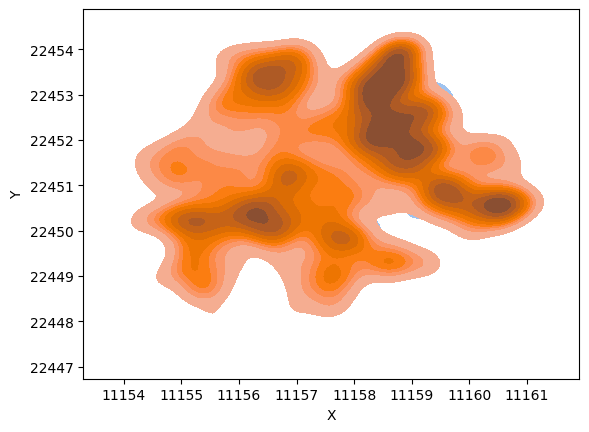

In [ ]:
parameters(ss, path_file='D:/lidar/data/orion/ex5_manual', path_csv='D:/lidar/data/orion/ex5_manual/STVOL_dd.csv')

In [7]:
from classes.PCD_TREE import PCD_TREE

In [8]:
pc_tree = PCD_TREE()
pc_tree.open('D:/lidar/data/orion/ex5_manual/t000000.txt')
pc_tree.RGBint = pc_tree.intensity/max(pc_tree.intensity)
import pandas as pd
df = pd.read_csv('D:/lidar/data/orion/ex5_manual/STVOL_dd.csv', sep=';')
fname = 't000000.txt'
pc_tree.estimate_height()
pc_tree.estimate_length()
pc_tree.search_main_coordinate(df, fname)
pc_slice = pc_tree.search_slice()
pc_expsph = pc_tree.search_points_for_center(pc_slice)

In [ ]:
pc_expsph.points, pc_expsph.points

(array([], shape=(0, 3), dtype=float64),
 array([], shape=(0, 3), dtype=float64))

In [13]:
pc_tree.estimate_diameter(pc_expsph, pc_slice)

ValueError: zero-size array to reduction operation minimum which has no identity

In [14]:
idx_labels = np.where(pc_expsph.points[:, 2] <= pc_expsph.points.min(axis=0)[2]+3)

ValueError: zero-size array to reduction operation minimum which has no identity

In [11]:
import numpy as np
idx_labels = np.where(pc_expsph.points[:, 2] <= pc_expsph.points.min(axis=0)[2]+3)

In [12]:
idx_labels

(array([    0,     1,     2, ..., 11160, 11161, 11162], dtype=int64),)

In [5]:
idx_labels = np.where(pc_expsph.points[:, 2] <= pc_expsph.points.min(axis=0)[2]+3)

NameError: name 'np' is not defined

In [4]:
import pandas as pd
df = pd.read_csv('D:/lidar/data/orion/ex5_manual/STVOL_dd.csv', sep=';')

In [11]:
df

,X,Y,Name_tree
0,11156.993,22451.667,T000000.txt
1,11148.656,22448.785,T000001.txt
2,11137.724,22447.603,T000002.txt
3,11135.026,22437.415,T000003.txt
4,11130.258,22438.798,T000004.txt
...,...,...,...
145,11250.362,22426.100,T000147.txt
146,11249.098,22427.544,T000148.txt
147,11156.673,22433.966,T000149.txt
148,11210.896,22419.292,T000150.txt


In [12]:
df.loc[df['Name_tree'] == 'T000000.txt', 'X']

0    11156.993
Name: X, dtype: float64

In [6]:
df['Name_tree'] == 't000000.txt'

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Name: Name_tree, Length: 150, dtype: bool

In [8]:
df['Name_tree'].str.lower() == 't000000.txt'

0       True
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Name: Name_tree, Length: 150, dtype: bool

In [ ]:
df.loc[df['Name_tree'] == fname, 'X'].values[0]